# 04 - K-Nearest Neighbors (KNN)

## Conceito
KNN classifica uma nova amostra olhando os K vizinhos mais proximos no
conjunto de treino e votando pela classe majoritaria. Para regressao,
usa a media dos K vizinhos.

## Caracteristicas
- Modelo "lazy": nao aprende parametros no treino, so armazena os dados
- Custo alto na previsao (O(n) por amostra em forca bruta)
- Sensivel a escala: precisa normalizar
- Sensivel a K: K pequeno gera overfitting, K grande gera underfitting

## Distancias
- Euclidiana (padrao)
- Manhattan
- Minkowski (generaliza as duas acima)

## Escolhendo K
- K impar ajuda a evitar empates em classificacao binaria
- Regra pratica: K = sqrt(n)
- Melhor: validacao cruzada em uma grade

## Quando usar
- Datasets pequenos ou medios
- Fronteiras de decisao complexas
- Baseline simples e interpretavel

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

iris = load_iris()
X, y = iris.data, iris.target # type: ignore

# KNN precisa de escala comparavel
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("X_train:", X_train_s.shape)

X_train: (120, 4)


In [2]:
# Comparando varios valores de K
ks = [1, 3, 5, 7, 9, 11, 15, 21]
resultados = []

for k in ks:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_s, y_train)
    acuracia = accuracy_score(y_test, modelo.predict(X_test_s))
    resultados.append(acuracia)
    print(f"K={k:<3} acuracia={acuracia:.3f}")

K=1   acuracia=0.967
K=3   acuracia=0.933
K=5   acuracia=0.933
K=7   acuracia=0.967
K=9   acuracia=0.967
K=11  acuracia=0.967
K=15  acuracia=0.967
K=21  acuracia=0.967


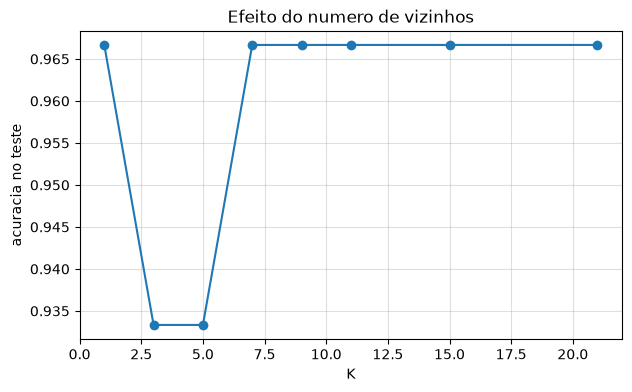

In [3]:
plt.figure(figsize=(7, 4))
plt.plot(ks, resultados, marker="o")
plt.xlabel("K")
plt.ylabel("acuracia no teste")
plt.title("Efeito do numero de vizinhos")
plt.grid(True, alpha=0.4)
plt.show()

## K por validacao cruzada

Escolher K olhando o conjunto de teste e vazamento. O correto e usar
validacao cruzada no conjunto de treino.

Melhor K (cv): 5
Acuracia media: 0.967


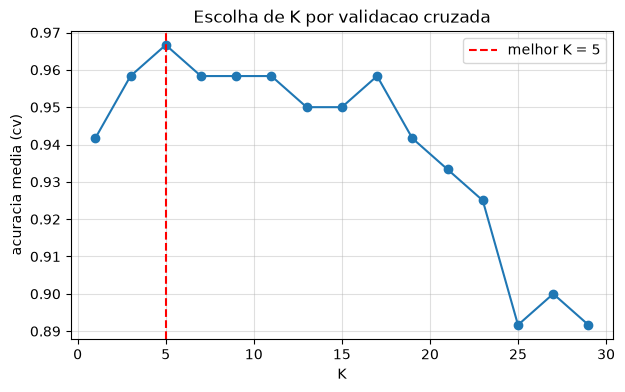

In [4]:
ks = list(range(1, 31, 2))
medias = []

for k in ks:
    modelo = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(modelo, X_train_s, y_train, cv=5)
    medias.append(scores.mean())

melhor_k = ks[int(np.argmax(medias))]
print("Melhor K (cv):", melhor_k)
print("Acuracia media:", round(max(medias), 3))

plt.figure(figsize=(7, 4))
plt.plot(ks, medias, marker="o")
plt.axvline(melhor_k, color="red", linestyle="--", label=f"melhor K = {melhor_k}")
plt.xlabel("K")
plt.ylabel("acuracia media (cv)")
plt.title("Escolha de K por validacao cruzada")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## Fronteira de decisao

Para visualizar, usamos apenas duas features e plotamos a regiao de decisao.

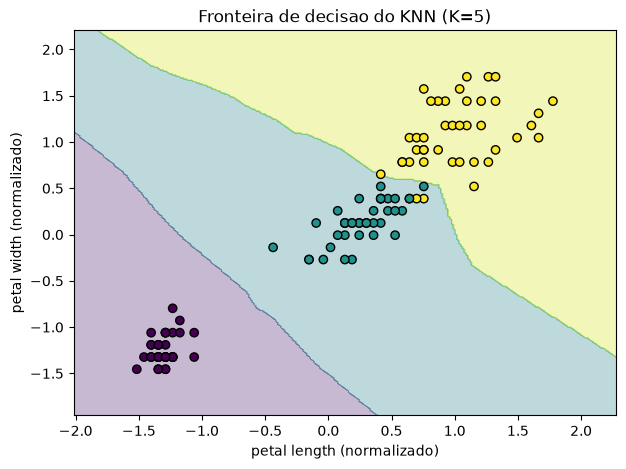

In [5]:
# Usando apenas duas features para visualizar
X2 = X[:, [2, 3]]  # petal length e petal width
X_tr, X_te, y_tr, y_te = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
sc = StandardScaler().fit(X_tr)
X_tr_s = sc.transform(X_tr)
X_te_s = sc.transform(X_te)

modelo = KNeighborsClassifier(n_neighbors=5).fit(X_tr_s, y_tr)

# Grade de pontos
x_min, x_max = X_tr_s[:, 0].min() - 0.5, X_tr_s[:, 0].max() + 0.5
y_min, y_max = X_tr_s[:, 1].min() - 0.5, X_tr_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
plt.scatter(X_tr_s[:, 0], X_tr_s[:, 1], c=y_tr, edgecolor="black", cmap="viridis")
plt.xlabel("petal length (normalizado)")
plt.ylabel("petal width (normalizado)")
plt.title("Fronteira de decisao do KNN (K=5)")
plt.show()

## Exercicios

1. Compare KNN com e sem normalizacao no dataset wine. O que muda?
2. Teste metric="manhattan" e metric="euclidean" e compare.
3. Plote a fronteira de decisao para K=1, K=15 e K=50 lado a lado.
4. Explique por que KNN e chamado de "lazy learner".